# Rule of Thumb — tabular quickstart

This notebook demonstrates the tabular RoT explainer on a small synthetic
problem: we define a toy "black box" classifier, fit a Rule-of-Thumb
surrogate to its outputs, and inspect the learned feature importances.

Everything runs on CPU with synthetic data in a few seconds.

In [1]:
import numpy as np

import ruleofthumb

In [2]:
# Synthetic data and a trivially simple "black box"
rng = np.random.RandomState(0)
n, d = 2000, 5
X = rng.randn(n, d).astype(np.float32)

def black_box(X):
    # logistic rule driven by features 0 and 2 only
    z = 2.0 * X[:, 0] - 1.5 * X[:, 2]
    return (1 / (1 + np.exp(-z)) > 0.5).astype(np.int64)  # int labels

y = black_box(X)

In [3]:
rot = ruleofthumb.fit(y_outputs=y, x_inputs=X, epochs=50, batch_size=500, learning_rate=0.05)
importances = rot.get_explanation(X)  # signed: positive = evidence toward class 1
importances[:3]

array([[ 2.4517567e+00,  1.7080612e-02, -8.5770380e-01, -5.5733621e-02,
        -5.6270387e-02],
       [-1.1825531e+00,  3.4171615e-02,  1.0992612e-01,  4.4374284e-03,
        -9.5292171e-03],
       [ 3.0403522e-01,  4.9840897e-02, -6.7130065e-01, -1.3353759e-03,
        -1.0596393e-02]], dtype=float32)

In [4]:
# Global feature ranking: mean |importance| per feature (a magnitude view
# for ranking only, like SHAP summary plots — the explanations themselves
# are signed). Features 0 and 2 should dominate.
mean_imp = np.abs(importances).mean(axis=0)
for i, v in enumerate(mean_imp):
    print(f"feature {i}: {v:.4f}")

feature 0: 1.0671
feature 1: 0.0242
feature 2: 0.6812
feature 3: 0.0205
feature 4: 0.0248


## Fidelity vs. number of revealed features

`score_ordering` reveals features most-important-first and measures how well
the partially-revealed RoT reproduces the black box's labels.

In [5]:
import torch

x_t = torch.from_numpy(X)
y_t = torch.from_numpy(y.astype(np.int64))
order = rot.get_order(x_t)
acc = rot.score_ordering(x_t, y_t, order)
print("accuracy after revealing k=1..d features:")
print(acc.numpy())

accuracy after revealing k=1..d features:
[0.5035 0.971  0.9745 0.974  0.9725 0.9725]


## Multiclass

The same pipeline works for any number of classes via `n_classes=`:
explanations come back per class (`[N, n_classes, d]`, signed), and
`score_ordering` defaults to plain accuracy, with an optional per-step
K×K confusion matrix via `return_confusion=True`.

In [6]:
# A 3-class black box driven by features 0 and 2
y3 = (X[:, 0] > 0.5).astype(np.int64) + (X[:, 2] > -0.5).astype(np.int64)  # labels in {0, 1, 2}

rot3 = ruleofthumb.fit(y_outputs=y3, x_inputs=X, epochs=50, batch_size=500, learning_rate=0.05, n_classes=3)
exp3 = rot3.get_explanation(X)
print("per-class explanations:", exp3.shape)  # (N, 3, d), signed

order3 = rot3.get_order(x_t)
acc3 = rot3.score_ordering(torch.from_numpy(X), torch.from_numpy(y3), order3)
print("multiclass accuracy curve:", acc3.numpy())

confusion3 = rot3.score_ordering(
    torch.from_numpy(X), torch.from_numpy(y3), order3, return_confusion=True
)
print("confusion after revealing all features (rows = true label):")
print(confusion3[-1].numpy())

per-class explanations: (2000, 3, 5)


multiclass accuracy curve: [0.5745 0.64   0.8025 0.8065 0.808  0.807 ]
confusion after revealing all features (rows = true label):
[[ 288  158    0]
 [  65 1022   62]
 [   0  101  304]]


## Visualising explanations

`ruleofthumb.plot` renders explanations in SHAP's signature styles.
Colour convention: **red = evidence toward the explained class,
blue = against**. Baseline semantics: the SHAP base value maps to the
RoT class bias $g_k$, and $f(x)$ maps to the surrogate score — RoT
explains its own surrogate of the black box (see the README for the
full mapping).


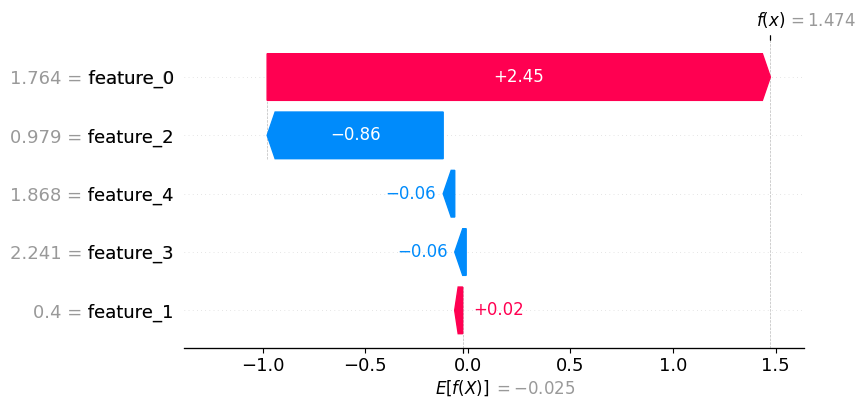

In [7]:
from ruleofthumb import plot

names = [f"feature_{i}" for i in range(X.shape[1])]

# one sample's signed contributions (binary explainer -> class 1 by default)
waterfall_fig = plot.waterfall(rot, X[:1], feature_names=names)


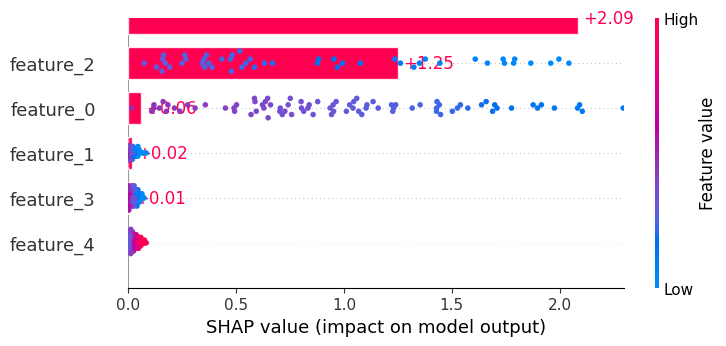

In [8]:
# global mean |importance| ranking over a batch, selectable per class;
# rot3 is the 3-class explainer fitted above
bar_fig = plot.bar(rot3, X[:200], feature_names=names, class_idx=2)
beeswarm_fig = plot.beeswarm(rot3, X[:200], feature_names=names, class_idx=0)


In [9]:
# every plotting function returns a matplotlib Figure — export anywhere
import os
import tempfile

path = os.path.join(tempfile.mkdtemp(), "waterfall.png")
waterfall_fig.savefig(path)
print("exported", os.path.getsize(path), "bytes to", path)


exported 25079 bytes to /var/folders/5y/12pqhhcj1jl__kkv_31jm3g40000gn/T/tmp2f5bke5q/waterfall.png
